## Name: Aryan Mahesh Patil
### Rollno: 46
#### Subject: DL
#### Experiment No: 7

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [23]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [24]:
train_data=datasets.STL10(root='./data',split='train',download=False,transform=transforms)
test_data=datasets.STL10(root='./data',split='test',download=False,transform=transforms)

train_dataset=Subset(train_data,range(1000))
test_dataset=Subset(test_data,range(500))

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

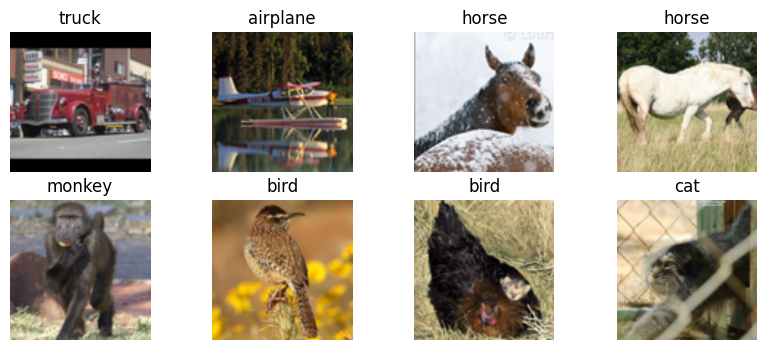

In [25]:
classes=['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
images,labels=next(iter(train_loader))
plt.figure(figsize=(10,4))
for i in range(8):
  plt.subplot(2,4,i+1)
  plt.imshow(images[i].permute(1,2,0))
  plt.title(classes[labels[i]])
  plt.axis('off')
plt.show()


In [26]:
model=models.resnet18(weights="DEFAULT")

for p in model.parameters():
  p.requires_grad=False

for p in model.layer4.parameters():
  p.requres_grad=True

model.fc=nn.Linear(model.fc.in_features,10)

In [27]:
model=model.to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [29]:
epochs=3

for epoch in range(epochs):
  model.train()
  for images,labels in train_loader:
    images, labels=images.to(device), labels.to(device)
    output=model(images)
    loss=criterion(output,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print("Epoch:",epoch+1,"Loss:",loss.item())
  model.eval()
  correct=0
  total=0

  with torch.no_grad():
    for images,labels in test_loader:
      images,labels=images.to(device),labels.to(device)
      output=model(images).argmax(1)
      total+=labels.size(0)
      correct+=(output==labels).sum().item()
  print(f"Accuracy: {100*correct/total:.2f}%")

Epoch: 1 Loss: 0.678409993648529
Accuracy: 90.80%
Epoch: 2 Loss: 0.5142294764518738
Accuracy: 92.40%
Epoch: 3 Loss: 0.2760602533817291
Accuracy: 92.80%
